# UCI HAR Dataset 기반 LSTM 분류

In [55]:
# 라이브러리 import
import numpy as np
import tensorflow as tf #딥러닝 프레임워크
import matplotlib.pyplot as plt # 학습 곡선 시각화(그래프)
import seaborn as sns #시각화

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, Input, LSTM
from tensorflow.keras.optimizers import Adam #optimizer
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau #학습 도중 자동 제어 장치

from sklearn.metrics import classification_report, confusion_matrix #학습 후 성능 분석용

In [56]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
# 경로 정의
DATASET_PATH = "/content/drive/MyDrive/UCI HAR Dataset/"

TRAIN = "train/"
TEST = "test/"

# 입력으로 사용할 9개의 센서 채널
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

# 혼동 행렬이나 결과 해석 시 읽기 쉬운 동작 이름 정의
LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [58]:
# X 데이터 로드 함수
def load_X(X_signals_paths):
    X_signals = [] # 전체 센서 채널(9개)을 담을 리스트

    # 센서 파일(9개)을 하나씩 순회
    for signal_type_path in X_signals_paths:
        signal_data = [] # 현재 센서 채널의 모든 샘플 데이터를 담을 리스트

        with open(signal_type_path, 'r') as file:
            for row in file:

                # 문자열 전처리
                # 1. 공백 정리
                # 2. 양끝 공백 제거
                # 3. 공백 기준으로 split -> 문자열 숫자 리스트로 변환
                row = row.replace('  ', ' ').strip().split(' ')

                # 문자열 → float32 숫자로 변환
                row = [np.float32(x) for x in row]

                # 하나의 sample을 리스트에 추가
                signal_data.append(row)

        # 현재 센서 채널 전체 데이터를 추가
        X_signals.append(signal_data)

    # 리스트 -> numpy 배열로 변환
    X_signals = np.array(X_signals)

    # LSTM 입력 형태로 변환
    # (channels, samples, time) -> (samples, time, channels)
    # 원래 shape: (9, samples, 128)
    # 변환 후 shape: (samples, 128, 9)
    return np.transpose(X_signals, (1, 2, 0))

In [59]:
# y 데이터 로드 함수
def load_y(y_path):
    y = [] # 전체 샘플의 정답 라벨을 담을 리스트
    with open(y_path, 'r') as file:
        for row in file:

            # 문자열 형태의 숫자를 읽어서 공백 제거 후 정수로 변환
            y.append(int(row.strip()))

    # 리스트 -> numpy 배열로 변환
    y = np.array(y, dtype=np.int32)

    # 원래 라벨이 1~6이라서 딥러닝에서 사용하 0~5로 변경
    return y - 1

In [60]:
# 데이터 로드

# train용 9개 센서 파일 경로를 리스트로 생성
X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]

# test용 9개 센서 파일 경로를 리스트로 생성
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

# train 입력 데이터 로드
X_train = load_X(X_train_signals_paths)
# test 입력 데이터 로드
X_test = load_X(X_test_signals_paths)

# train 정답 라벨 로드
y_train = load_y(DATASET_PATH + TRAIN + "y_train.txt")
# test 정답 라벨 로드
y_test = load_y(DATASET_PATH + TEST + "y_test.txt")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)
y_train shape: (7352,)
y_test shape: (2947,)


In [61]:
# LSTM은 (timesteps, features) 입력 구조
input_shape = (X_train.shape[1], X_train.shape[2])
# 분류할 동작 개수
num_classes = 6

# 모델 정의 (Sequential: 층을 순서대로 쌓는 구조)
model = Sequential([
    Input(shape=input_shape),

    # 첫 번째 LSTM 레이어
    LSTM(128, return_sequences=True, dropout=0.2),
    # 두 번째 LSTM 레이어
    LSTM(64, return_sequences=False, dropout=0.2),

    # LSTM이 뽑은 특징을 기반으로 비선형 변환
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
            optimizer = Adam(learning_rate=0.0005),
            # 정답이 정수 라벨 (0~5)일 때 사용하는 다중 분류용 손실 함수
            loss='sparse_categorical_crossentropy',
            metrics=['sparse_categorical_accuracy']
        )

print(model.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 128, 128)       │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,342 (477.90 KB)

 Trainable params: 122,342 (477.90 KB)

 Non-trainable params: 0 (0.00 B)

None


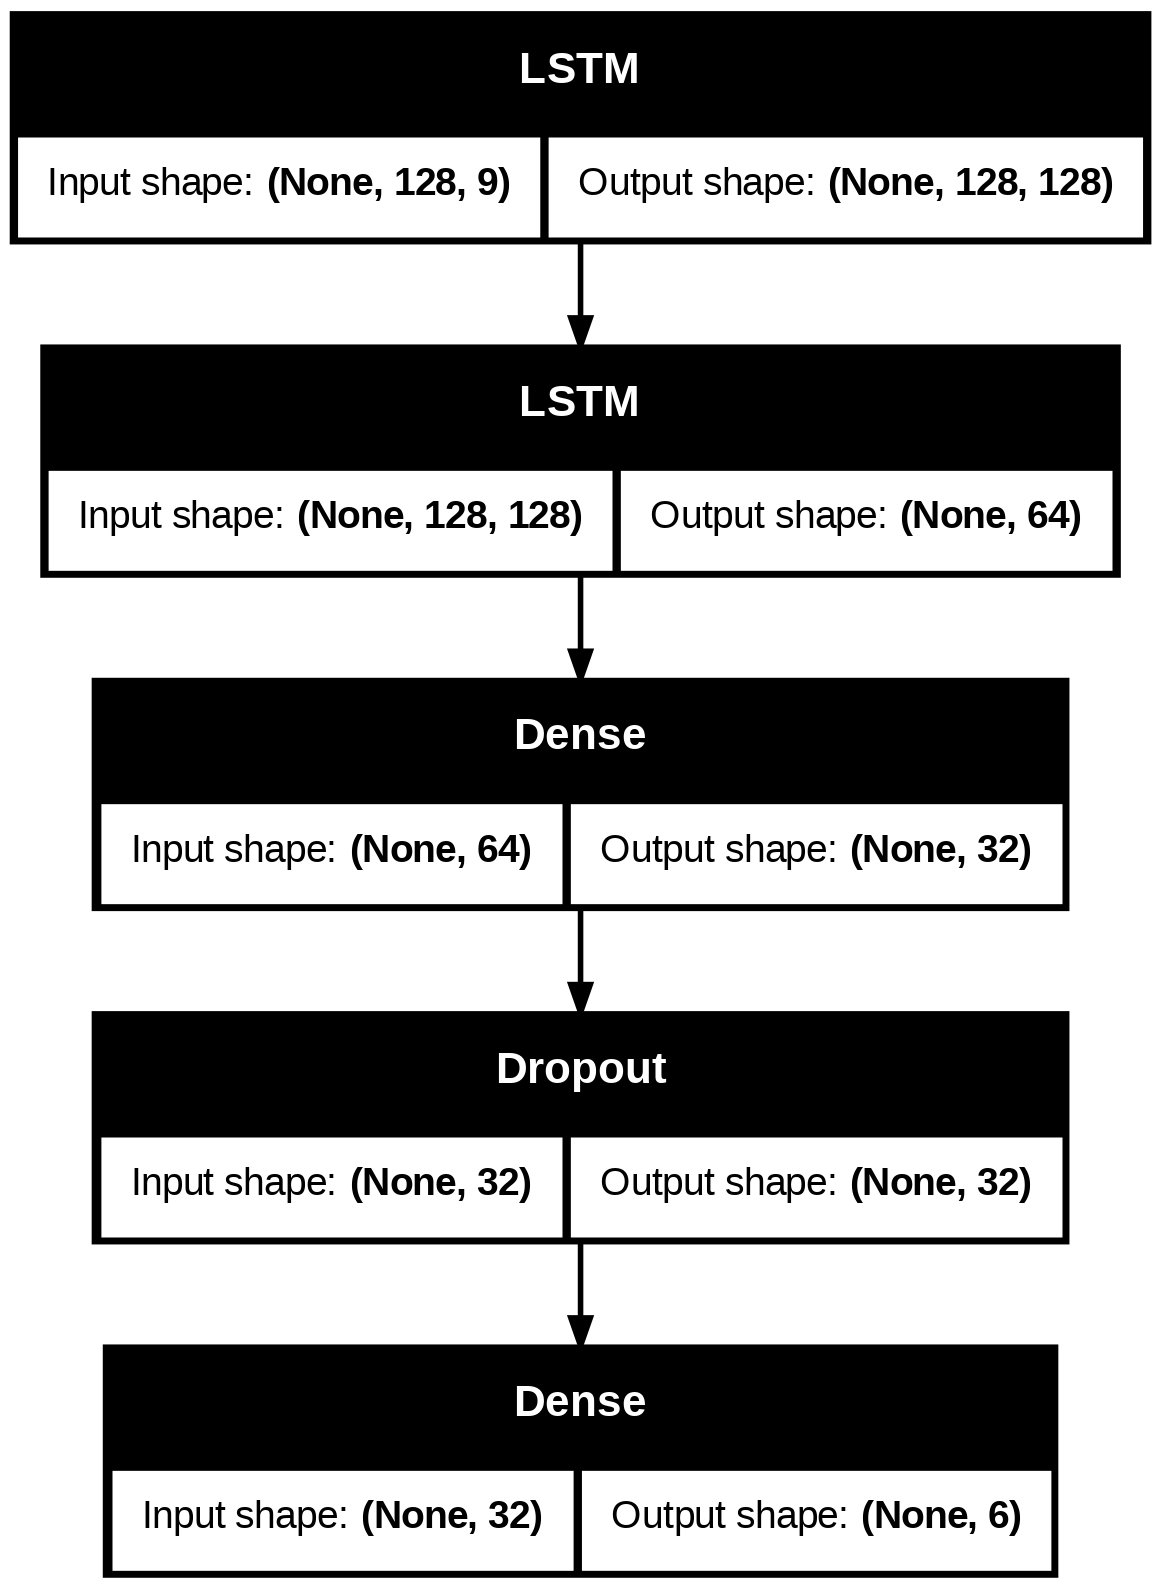

In [62]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [63]:
# Callback 설정(학습 중 자동으로 개입)
callbacks = [
    # 가장 성능이 좋은 모델을 파일로 저장
    ModelCheckpoint(
        "UCI_HAR_LSTM_best.keras",
        save_best_only=True,
        monitor="val_sparse_categorical_accuracy",
        mode='max',
        verbose=1
    ),
    # 조기 종료 : 더 이상 성능이 좋아지지 않으면 학습 종료
    EarlyStopping(
        monitor="val_sparse_categorical_accuracy",
        patience=25,
        verbose=1,
        mode='max',
        restore_best_weights=True
    ),
    # 학습이 정체되면 learning rate 감소
    ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
    )
]

In [64]:
# 모델 학습
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
    shuffle=True
)

Epoch 1/100
102/104 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.5591 - sparse_categorical_accuracy: 0.3358
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.66033, saving model to UCI_HAR_LSTM_best.keras

Epoch 1: finished saving model to UCI_HAR_LSTM_best.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 1.3675 - sparse_categorical_accuracy: 0.4244 - val_loss: 0.7791 - val_sparse_categorical_accuracy: 0.6603 - learning_rate: 5.0000e-04
Epoch 2/100
102/104 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0648 - sparse_categorical_accuracy: 0.5518
Epoch 2: val_sparse_categorical_accuracy improved from 0.66033 to 0.69973, saving model to UCI_HAR_LSTM_best.keras

Epoch 2: finished saving model to UCI_HAR_LSTM_best.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.9861 - sparse_categorical_accuracy: 0.5676 - val_loss: 0.6517 - val_sparse_categorical_accuracy: 0.6997 - learning_rate: 5.0000e-04
Epoch 3/100
102/104 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8112 - sp

In [65]:
# 모델 평가
model = tf.keras.models.load_model("UCI_HAR_LSTM_best.keras")

# 학습 및 테스트 성능 평가
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 91.53%
Training loss: 0.1859
Test accuracy: 89.31%
Test loss: 0.2856


In [66]:
# 예측 및 분류 리포트
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9415    0.9699       496
           1     0.9768    0.9851    0.9810       471
           2     0.9195    0.9786    0.9481       420
           3     0.7238    0.7312    0.7275       491
           4     0.7743    0.8383    0.8051       532
           5     0.9979    0.9032    0.9482       537

    accuracy                         0.8931      2947
   macro avg     0.8987    0.8963    0.8966      2947
weighted avg     0.8977    0.8931    0.8945      2947



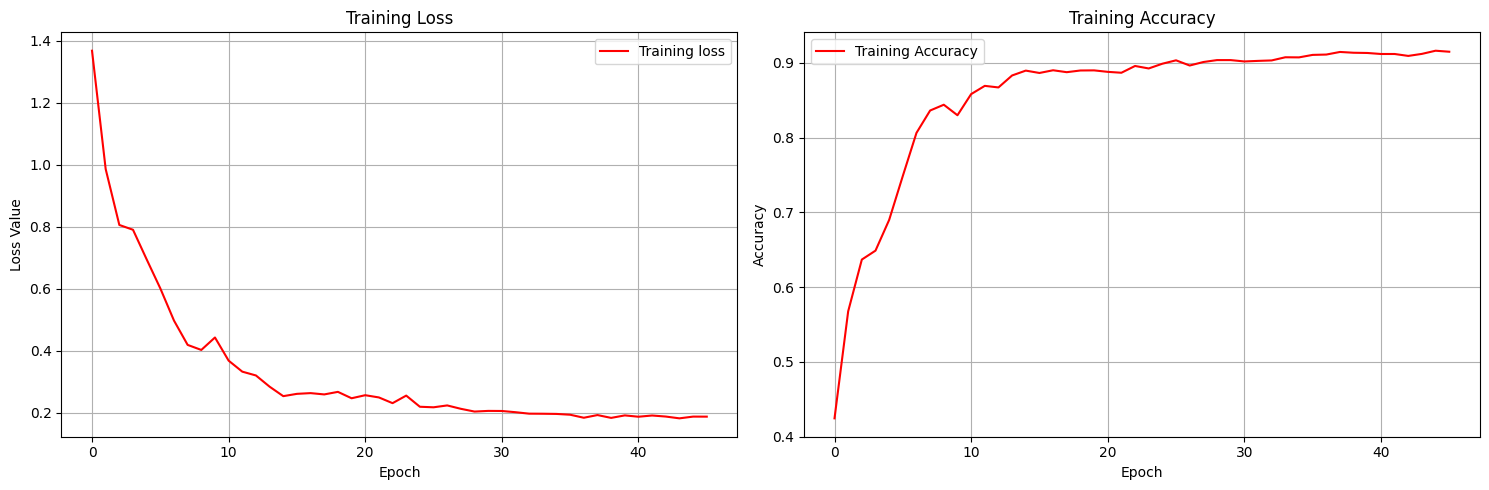

In [67]:
# 학습 곡선 시각화
train_loss = history.history['loss']
train_accuracy = history.history['sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

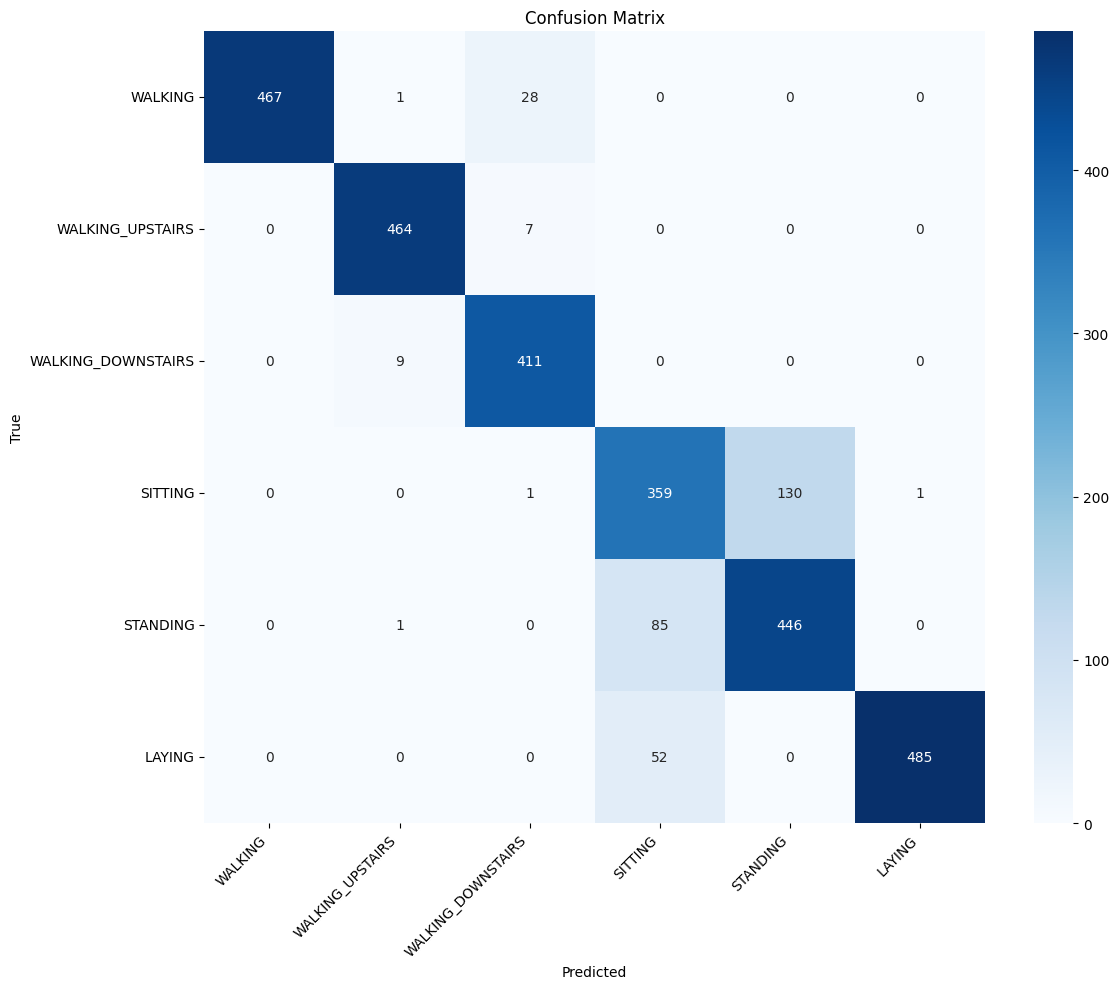

In [68]:
# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

n_classes = len(np.unique(y_test))
if n_classes <= len(LABELS):
    plt.gca().set_xticklabels(LABELS[:n_classes], rotation=45, ha='right')
    plt.gca().set_yticklabels(LABELS[:n_classes], rotation=0)

plt.tight_layout()
plt.show()